In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import sys
import os
import pathlib
import pickle

from omegaconf import OmegaConf

In [2]:
path = pathlib.Path(r'C:\Users\Vladimir\PycharmProjects\EEGPatternRecognition\dumps')

path

WindowsPath('C:/Users/Vladimir/PycharmProjects/EEGPatternRecognition/dumps')

In [11]:
run_info_ls = []

adj_seed_ls=np.array([428, 11923, 445, 5794, 14642, 43219, 2267, 11469, 15392, 1108, 665, 1462, 32026, 59966, 377, 269])
weights_seed_ls=np.array([428, 11923, 445, 5794, 14642, 43219, 2267, 11469, 15392, 1108, 665, 1462, 32026, 59966, 377, 269])
run_name = "neighbors_init"

for adj_seed, weights_seed in zip(adj_seed_ls, weights_seed_ls):
    with open(path / f"dump_{run_name}_seed_11923_adj_11923.bin", 'rb') as f:
        run_info = pickle.load(f)
    
    run_info_ls.append(run_info)

In [13]:
run_info_ls[0]

{'train_curve': {'train': {'TP': [5175,
    6346,
    6987,
    6929,
    6850,
    7074,
    7436,
    7475,
    7524,
    7720,
    7751,
    7793,
    7808,
    7913,
    7898,
    7956,
    7937,
    8080,
    7995,
    7987,
    8154,
    8152,
    8065,
    8130,
    8129,
    8255,
    8128,
    8199,
    8160,
    8176,
    8190,
    8280,
    8226,
    8156,
    8251,
    8232,
    8342,
    8327,
    8187,
    8230,
    8264,
    8254,
    8254,
    8260,
    8286,
    8191,
    8385,
    8206,
    8273,
    8172,
    8306,
    8366,
    8230,
    8303,
    8308,
    8354,
    8286,
    8391,
    8227,
    8311,
    8353,
    8403,
    8413,
    8399,
    8389,
    8361,
    8496,
    8348,
    8363,
    8405,
    8355,
    8328,
    8365,
    8312,
    8408,
    8365,
    8445,
    8395,
    8337,
    8391,
    8411,
    8466,
    8411,
    8407,
    8394,
    8441,
    8484,
    8449,
    8364,
    8434,
    8413,
    8483,
    8347,
    8396,
    8457,
    8468,
    8503,


Step with best F1 score: 77


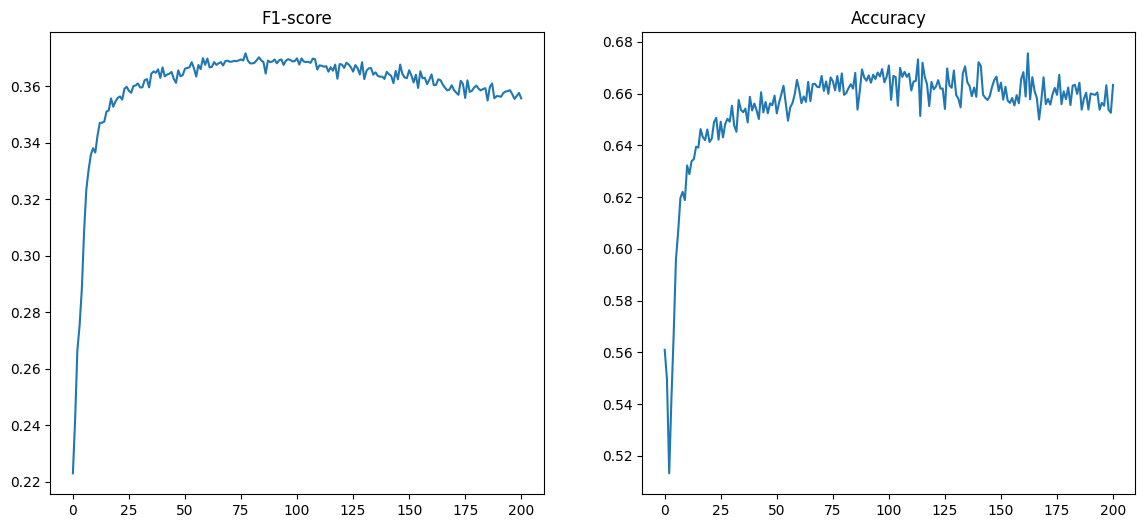

In [15]:
_, ax = plt.subplots(ncols=2, figsize=(14, 6))

ax[0].plot(run_info_ls[0]['train_curve']['validation']['f1'])
ax[1].plot(run_info_ls[0]['train_curve']['validation']['accuracy'])

ax[0].set_title('F1-score')
ax[1].set_title('Accuracy')


best_idx = np.argmax(run_info_ls[0]['train_curve']['validation']['f1'])

print(f"Step with best F1 score: {best_idx}")

In [16]:
f1_ls = []
accuracy_ls = []

for run_info in run_info_ls:
    f1_ls.append(run_info['train_curve']['validation']['f1'])
    accuracy_ls.append(run_info['train_curve']['validation']['accuracy'])

f1_ls = np.vstack(f1_ls)
accuracy_ls = np.vstack(accuracy_ls)

print(f"{f1_ls.shape=}\t{accuracy_ls.shape=}")

f1_ls.shape=(16, 201)	accuracy_ls.shape=(16, 201)


Step with best mean F1 score: 77


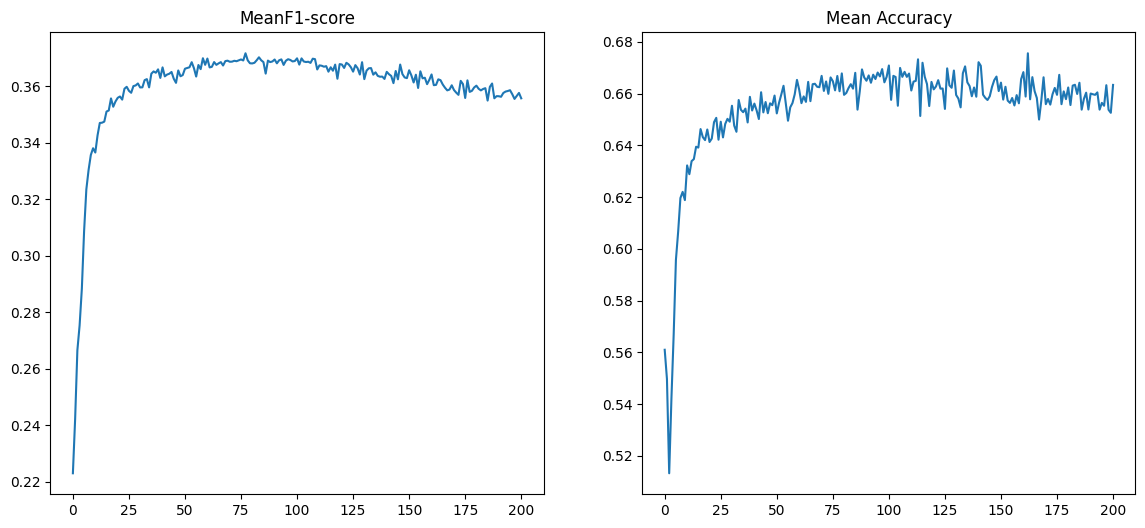

In [17]:
_, ax = plt.subplots(ncols=2, figsize=(14, 6))

ax[0].plot(np.mean(f1_ls, axis=0))
ax[1].plot(np.mean(accuracy_ls, axis=0))

ax[0].set_title('MeanF1-score')
ax[1].set_title('Mean Accuracy')

best_idx = np.argmax(np.mean(f1_ls, axis=0))

print(f"Step with best mean F1 score: {best_idx}")

Step with best F1 score: 77


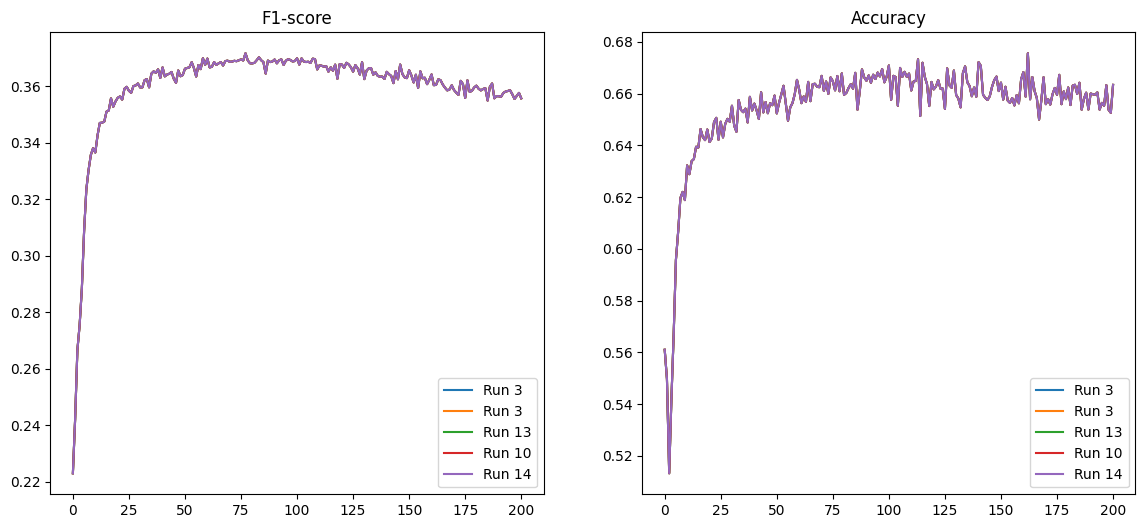

In [19]:
_, ax = plt.subplots(ncols=2, figsize=(14, 6))

sample_idxs = np.random.randint(low=0, high=len(run_info_ls) - 1, size=5)

for sample_idx in sample_idxs:
    ax[0].plot(run_info_ls[sample_idx]['train_curve']['validation']['f1'], label=f'Run {sample_idx}')
    ax[1].plot(run_info_ls[sample_idx]['train_curve']['validation']['accuracy'], label=f'Run {sample_idx}')

ax[0].set_title('F1-score')
ax[1].set_title('Accuracy')
ax[0].legend()
ax[1].legend()

best_idx = np.argmax(run_info_ls[0]['train_curve']['validation']['f1'])

print(f"Step with best F1 score: {best_idx}")

In [20]:
best_step_idxs = np.zeros(f1_ls.shape[0])
best_f1_ls = np.zeros_like(best_step_idxs)
best_acc_ls = np.zeros_like(best_step_idxs)

for i, run_info in enumerate(run_info_ls):
    best_idx = np.argmax(run_info['train_curve']['validation']['f1'])
    best_step_idxs[i] = best_idx
    best_f1_ls[i] = run_info['train_curve']['validation']['f1'][best_idx]
    best_acc_ls[i] = run_info['train_curve']['validation']['accuracy'][best_idx]

    print(f"Record pos: {i}\tStep with best F1 score: {best_idx}\tF1-score: {best_f1_ls[i]}\tAccuracy: {best_acc_ls[i]}")

Record pos: 0	Step with best F1 score: 77	F1-score: 0.37167399958097636	Accuracy: 0.6667777777777778
Record pos: 1	Step with best F1 score: 77	F1-score: 0.37167399958097636	Accuracy: 0.6667777777777778
Record pos: 2	Step with best F1 score: 77	F1-score: 0.37167399958097636	Accuracy: 0.6667777777777778
Record pos: 3	Step with best F1 score: 77	F1-score: 0.37167399958097636	Accuracy: 0.6667777777777778
Record pos: 4	Step with best F1 score: 77	F1-score: 0.37167399958097636	Accuracy: 0.6667777777777778
Record pos: 5	Step with best F1 score: 77	F1-score: 0.37167399958097636	Accuracy: 0.6667777777777778
Record pos: 6	Step with best F1 score: 77	F1-score: 0.37167399958097636	Accuracy: 0.6667777777777778
Record pos: 7	Step with best F1 score: 77	F1-score: 0.37167399958097636	Accuracy: 0.6667777777777778
Record pos: 8	Step with best F1 score: 77	F1-score: 0.37167399958097636	Accuracy: 0.6667777777777778
Record pos: 9	Step with best F1 score: 77	F1-score: 0.37167399958097636	Accuracy: 0.6667777

<Axes: >

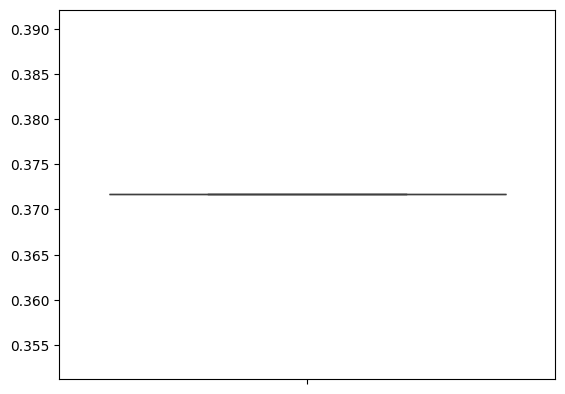

In [21]:
sns.boxplot(best_f1_ls)